# Low-rank RNNs, end to end

## tl;dr

This notebook follows two rank-two networks as separate experiments.

- **Network A** starts from random weights and is trained on the literal
  fixed-delay task. It solves that task with a coupled oscillatory trajectory.
- **Network B** starts from the covariance structure suggested in the
  handout and is trained on dense frequencies and randomized delays. It
  develops separately readable persistent and transient modes.

Each network is analyzed with the same reconstruction pipeline:

**train → identify dynamics → fit its post-training six-dimensional
loading Gaussian → test finite Gaussian RNN samples → test two reduced
circuits → compare behavior.**

The two reduced circuits answer different questions:

1. The **full-covariance Gaussian circuit** uses the fitted loading means
   and every entry of the fitted covariance.
2. The **handout diagonal circuit** uses that same network's fitted
   \(\operatorname{Cov}(n_r,m_r)\), \(\operatorname{Cov}(n_r,I)\), and
   \(\operatorname{Cov}(w,m_r)\), plus the fitted \(m_r\) and \(I\)
   variances. It sets loading means, cross-mode couplings, and basis
   cross-covariances to zero.

The native-protocol reconstruction results remain distinct:

- Network A: trained \(0.0008\), full covariance \(0.0180\), diagonal
  \(0.9847\).
- Network B, worst of the four reported delays: trained \(0.0024\), full
  covariance \(0.0043\), diagonal \(0.0062\).

A separate **matched behavioral benchmark** then gives both trained
networks the exact same 49 conditions, inputs, targets, and decision windows.
A wins on its native fixed schedule (MSE \(0.000788\) vs \(0.058812\)).
Across the common 500–2000 ms variable-delay sweep, A's mean/worst MSE is
\(0.114628/0.303430\), whereas B's is \(0.001945/0.002446\).

All behavioral comparisons use one definition: MSE of each trial's mean
five-step decision. The paper coefficients used to initialize Network B,
Network A's fitted covariance, and Network B's fitted covariance remain
three distinct objects throughout.

## 0. Setup and shared conventions

We use the repository's `LowRankRNN` throughout:

\[
\tau \dot x
= -x + \frac{1}{N}MN^\top \tanh(x) + Iu,
\qquad
z = \frac{1}{N}w^\top\tanh(x).
\]

`M` and `N` have shape \(N\times R\), so changing `rank=R` is the only
model change between the exercises. Forward Euler uses
\(\Delta t/\tau=20/100=0.2\). Only `m` and `n` train; `I` and `w` remain
fixed. The readout starts with standard deviation 4 so its finite-population
signal is visible without making it trainable.

### Notation fixes from the handout

- A standard Gaussian average has prefactor \(1/\sqrt{2\pi}\), not
  \(1/(2\pi)\).
- The rank-one variance is a function of the **filtered input** \(v\), not
  the instantaneous input \(u\).
- Mean-field \(\kappa\) is the coefficient in \(x\approx M\kappa+Iv\);
  it is obtained with a pseudoinverse. A unit-axis projection
  \(m^\top x/\lVert m\rVert\) has a different scale.
- The handout omits the reduced readout. We include it because otherwise the
  reduced circuit cannot be tested on the task.

In [1]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from low_rank_rnn import analysis, mean_field, plotting
from low_rank_rnn.data import perceptual_decision_making as decision_task
from low_rank_rnn.data import working_memory as memory_task
from low_rank_rnn.model import LowRankRNN, persistent_transient_rnn
from low_rank_rnn.training import (
    decision_accuracy,
    train_model,
    train_variable_delay,
)

plotting.set_plot_style()
BASE_SEED = 2026
NUM_UNITS = 128
TASK_MSE_THRESHOLD = 5e-3
NUM_GAUSSIAN_NETWORKS = 10
REPORT_FIGURE_DIRECTORY = Path("report/figures")


def save_report_figure(figure: plt.Figure, filename: str) -> Path:
    """Save a notebook figure as a vector PDF for the LaTeX report."""
    REPORT_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    output_path = REPORT_FIGURE_DIRECTORY / filename
    figure.savefig(output_path, format="pdf")
    return output_path


Matplotlib is building the font cache; this may take a moment.


## 1. Rank-one perceptual decision-making

### 1.1 Generate the noisy evidence

Each 75-step trial draws one signed strength

\[
\bar{\mu} \in \pm 0.032\{1,2,4,8,16\},
\qquad
y=\operatorname{sign}(\bar{\mu}),
\]

and independent noise \(\xi(t)\sim\mathcal N(0,0.03^2)\). The stimulus is
present for \(5\le t\le45\); the final 15 steps form the decision window.
Weak evidence can be comparable to one instantaneous noise sample, so the
network must integrate across time.

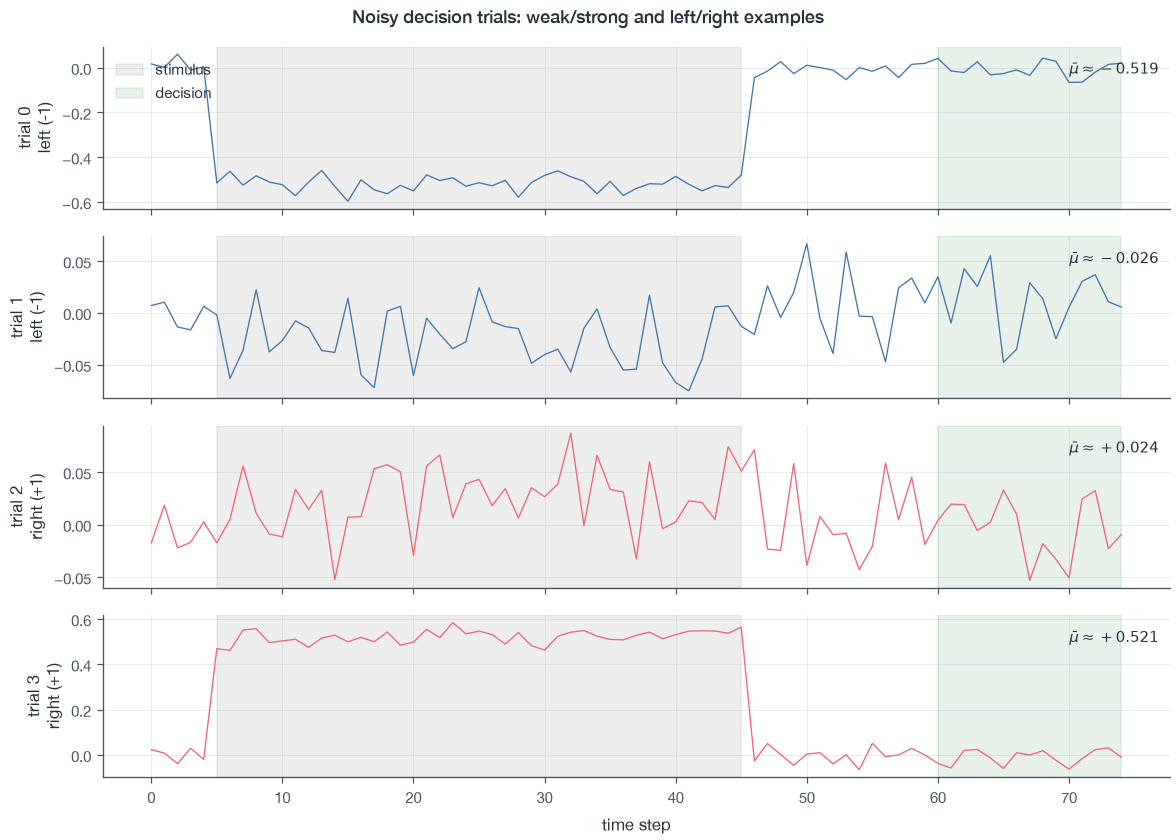

Allowed signed strengths: [-0.512 -0.256 -0.128 -0.064 -0.032  0.032  0.064  0.128  0.256  0.512]
Input shape: (80, 75) label shape: (80,)


In [2]:
preview_inputs, preview_labels = decision_task.generate_trials(
    num_trials=80,
    rng=np.random.default_rng(BASE_SEED),
)
preview_means = decision_task.mean_stimulus(preview_inputs)
preview_indices = decision_task.representative_trial_indices(
    preview_inputs,
    preview_labels,
)

rank1_decision_trials_figure, _ = plotting.plot_decision_trials(
    preview_inputs[preview_indices],
    preview_labels[preview_indices],
    mean_stimuli=preview_means[preview_indices],
)
save_report_figure(
    rank1_decision_trials_figure,
    "rank1-decision-task-trials.pdf",
)
plt.show()

print(
    "Allowed signed strengths:",
    np.round(np.sort(decision_task.STIMULUS_STRENGTHS), 3),
)
print("Input shape:", preview_inputs.shape, "label shape:", preview_labels.shape)


### 1.2 Train the shared model at rank one

The low-rank multiplication is performed as
\(m[n^\top\phi(x)/N]\), so the code never materializes the \(N\times N\)
recurrent matrix. Training minimizes MSE only over the final 15 steps,
with Adam, learning rate \(5\times10^{-3}\), and batches of 32.

The repository helper calls one pass over the fixed training set an *epoch*.
Because there are several batches per epoch, the number of optimizer updates is
`epochs × ceil(num_trials / batch_size)`.

In [3]:
RANK1_DECISION_STEPS = 15
RANK1_TRAIN_TRIALS = 200
RANK1_EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 5e-3

rank1_train_inputs, rank1_train_labels = decision_task.generate_trials(
    num_trials=RANK1_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED + 1),
)
rank1_test_inputs, rank1_test_labels = decision_task.generate_trials(
    num_trials=256,
    rng=np.random.default_rng(BASE_SEED + 2),
)

torch.manual_seed(BASE_SEED)
rank1_model = LowRankRNN(n_units=NUM_UNITS, rank=1)
fixed_input_before = rank1_model.I.clone()
fixed_readout_before = rank1_model.w.clone()
rank1_losses = train_model(
    rank1_model,
    torch.as_tensor(rank1_train_inputs, dtype=torch.float32),
    torch.as_tensor(rank1_train_labels, dtype=torch.float32),
    epochs=RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=RANK1_DECISION_STEPS,
    log_every=100,
)

# The rank-one factorization is sign-indeterminate: flipping both m and n
# leaves the recurrent connectivity unchanged. Orient it so positive latent
# activity maps to the +1 (red/right) readout throughout the notebook.
with torch.no_grad():
    m_centered = rank1_model.m[:, 0] - rank1_model.m[:, 0].mean()
    w_centered = rank1_model.w - rank1_model.w.mean()
    if torch.dot(m_centered, w_centered) < 0:
        rank1_model.m[:, 0].mul_(-1)
        rank1_model.n[:, 0].mul_(-1)

rank1_outputs, rank1_states = analysis.run_model(rank1_model, rank1_test_inputs)
rank1_decisions = analysis.decision_values(
    rank1_outputs,
    RANK1_DECISION_STEPS,
)
rank1_test_mse, _ = analysis.regression_metrics(
    rank1_decisions,
    rank1_test_labels,
)
rank1_accuracy = float(
    np.mean(np.where(rank1_decisions >= 0, 1, -1) == rank1_test_labels)
)
rank1_updates = RANK1_EPOCHS * ceil(RANK1_TRAIN_TRIALS / BATCH_SIZE)

assert rank1_losses[-1] < 5e-2
assert torch.equal(rank1_model.I, fixed_input_before)
assert torch.equal(rank1_model.w, fixed_readout_before)

print(f"Optimizer updates:      {rank1_updates}")
print(f"Final training loss:    {rank1_losses[-1]:.6f}  (target < 0.05)")
print(f"Held-out decision MSE: {rank1_test_mse:.6f}")
print(f"Held-out sign accuracy:{rank1_accuracy:8.1%}")


Epoch 100: loss=0.000300


Epoch 200: loss=0.000121


Epoch 300: loss=0.000088
Optimizer updates:      2100
Final training loss:    0.000088  (target < 0.05)
Held-out decision MSE: 0.000048
Held-out sign accuracy:  100.0%


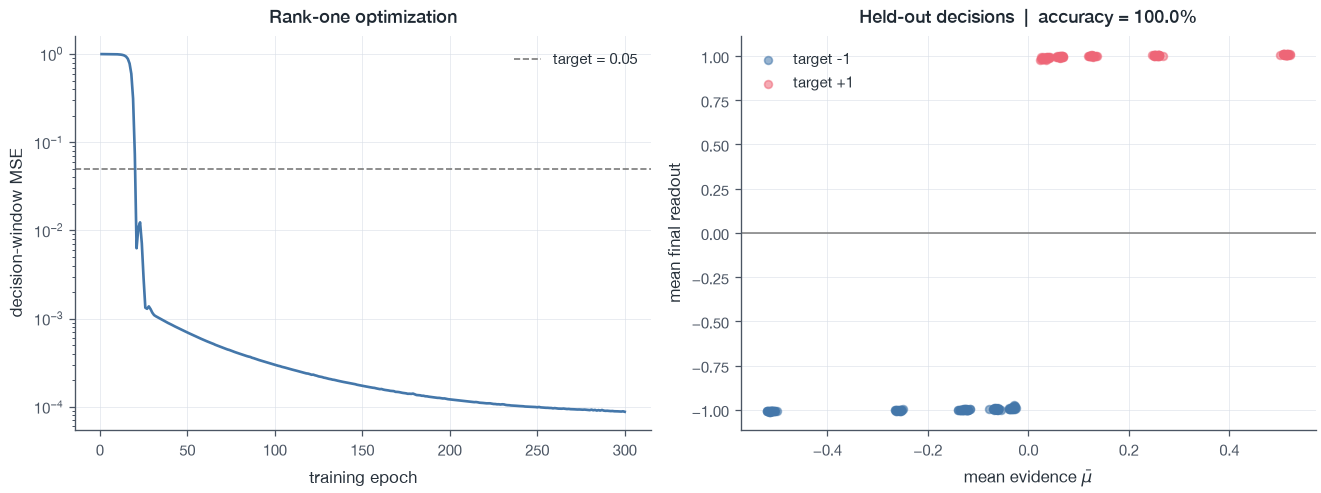

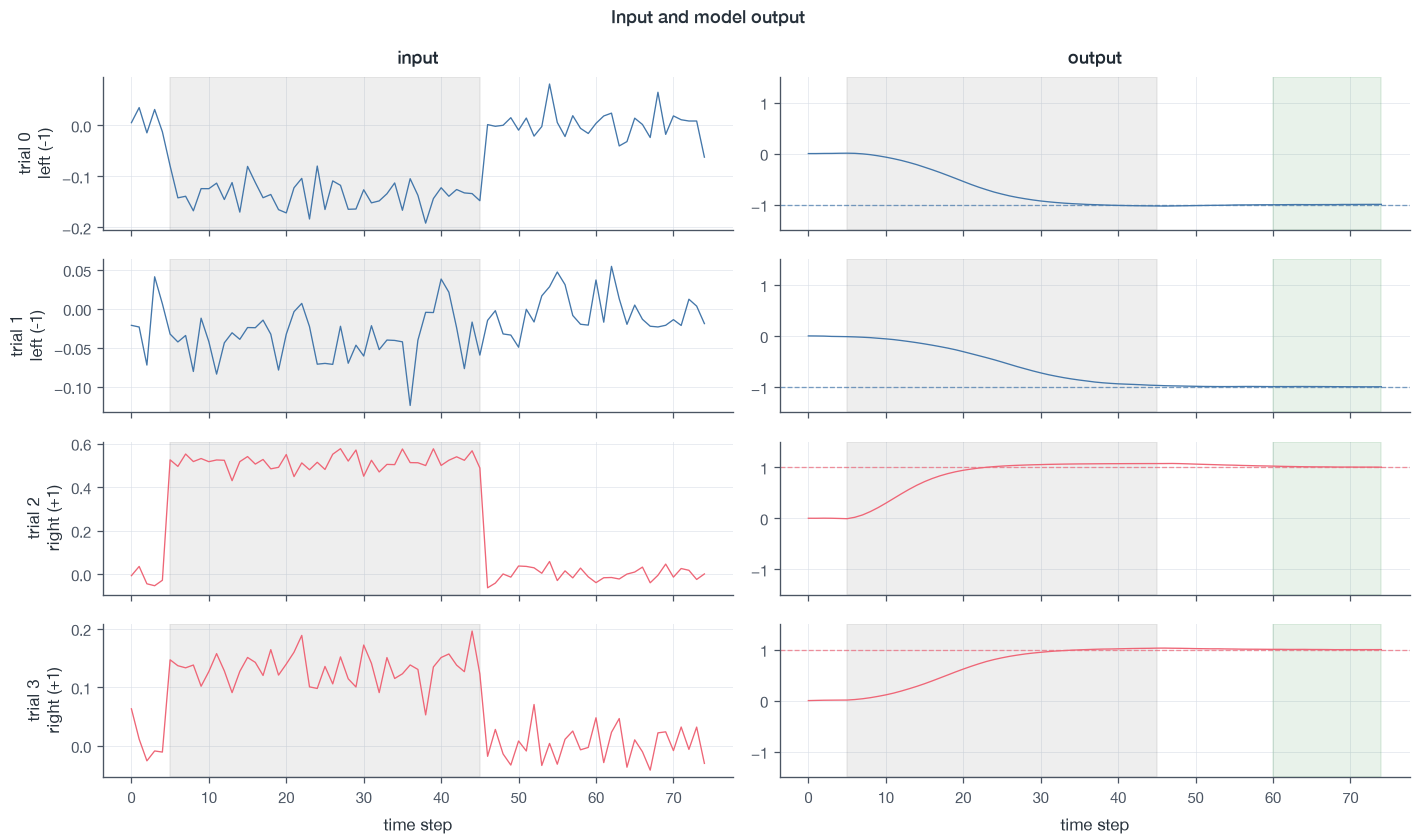

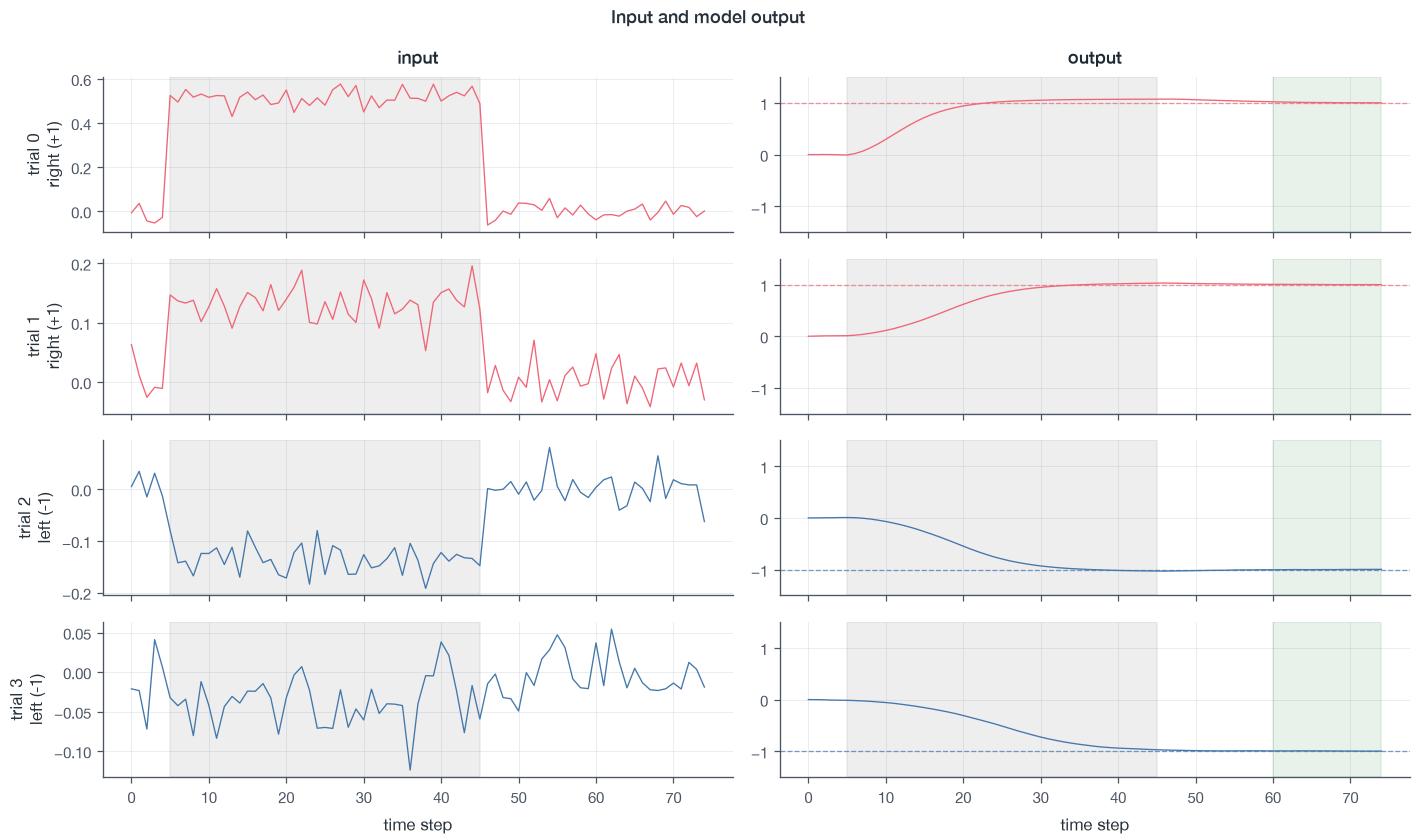

In [4]:
stimulus_estimates = decision_task.mean_stimulus(rank1_test_inputs)
rank1_training_summary_figure, _ = plotting.plot_decision_summary(
    rank1_losses,
    stimulus_estimates,
    rank1_decisions,
    rank1_test_labels,
    accuracy=rank1_accuracy,
    loss_threshold=5e-2,
)
save_report_figure(
    rank1_training_summary_figure,
    "rank1-training-summary.pdf",
)
plt.show()

positive_examples = np.flatnonzero(rank1_test_labels > 0)[:2]
negative_examples = np.flatnonzero(rank1_test_labels < 0)[:2]
rank1_examples = np.concatenate((negative_examples, positive_examples))
rank1_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_examples],
    rank1_test_labels[rank1_examples],
    rank1_outputs[rank1_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_input_output_figure,
    "rank1-input-output-examples.pdf",
)
plt.show()

rank1_training_examples = np.concatenate((positive_examples, negative_examples))
rank1_training_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_training_examples],
    rank1_test_labels[rank1_training_examples],
    rank1_outputs[rank1_training_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_training_input_output_figure,
    "rank1-training-input-output.pdf",
)
plt.show()


### 1.3 Connectivity explains the computation

A neuron is one point in four-dimensional loading space
\((I,n,m,w)\). Three cross-covariances form the useful path:

1. \(\operatorname{Cov}(n,I)\) routes the input into the recurrent latent.
2. \(\operatorname{Cov}(m,n)\) feeds that latent back into itself.
3. \(\operatorname{Cov}(m,w)\) maps the recurrent state to the output.

The signs of the first and third terms may both flip: replacing
\(m\to-m,\ n\to-n\) leaves \(J=mn^\top/N\) unchanged. To remove that visual
ambiguity, we orient the equivalent factorization so
\(\operatorname{Cov}(m,w)>0\): positive latent activity points toward the
red/right \((+1)\) choice, and negative latent activity toward the blue/left
\((-1)\) choice. The invariant story remains the complete input → recurrence
→ readout path, not one loading vector's raw sign.

For comparison, the handout's paper circuit uses
\(\sigma_{mn}=1.4,\sigma_{nI}=2.6,\sigma_{mw}=2.1\). With this sign
convention, the run has approximately
\((1.59,0.65,2.04)\): the recurrent and readout couplings closely match,
while its fitted input coupling is weaker.

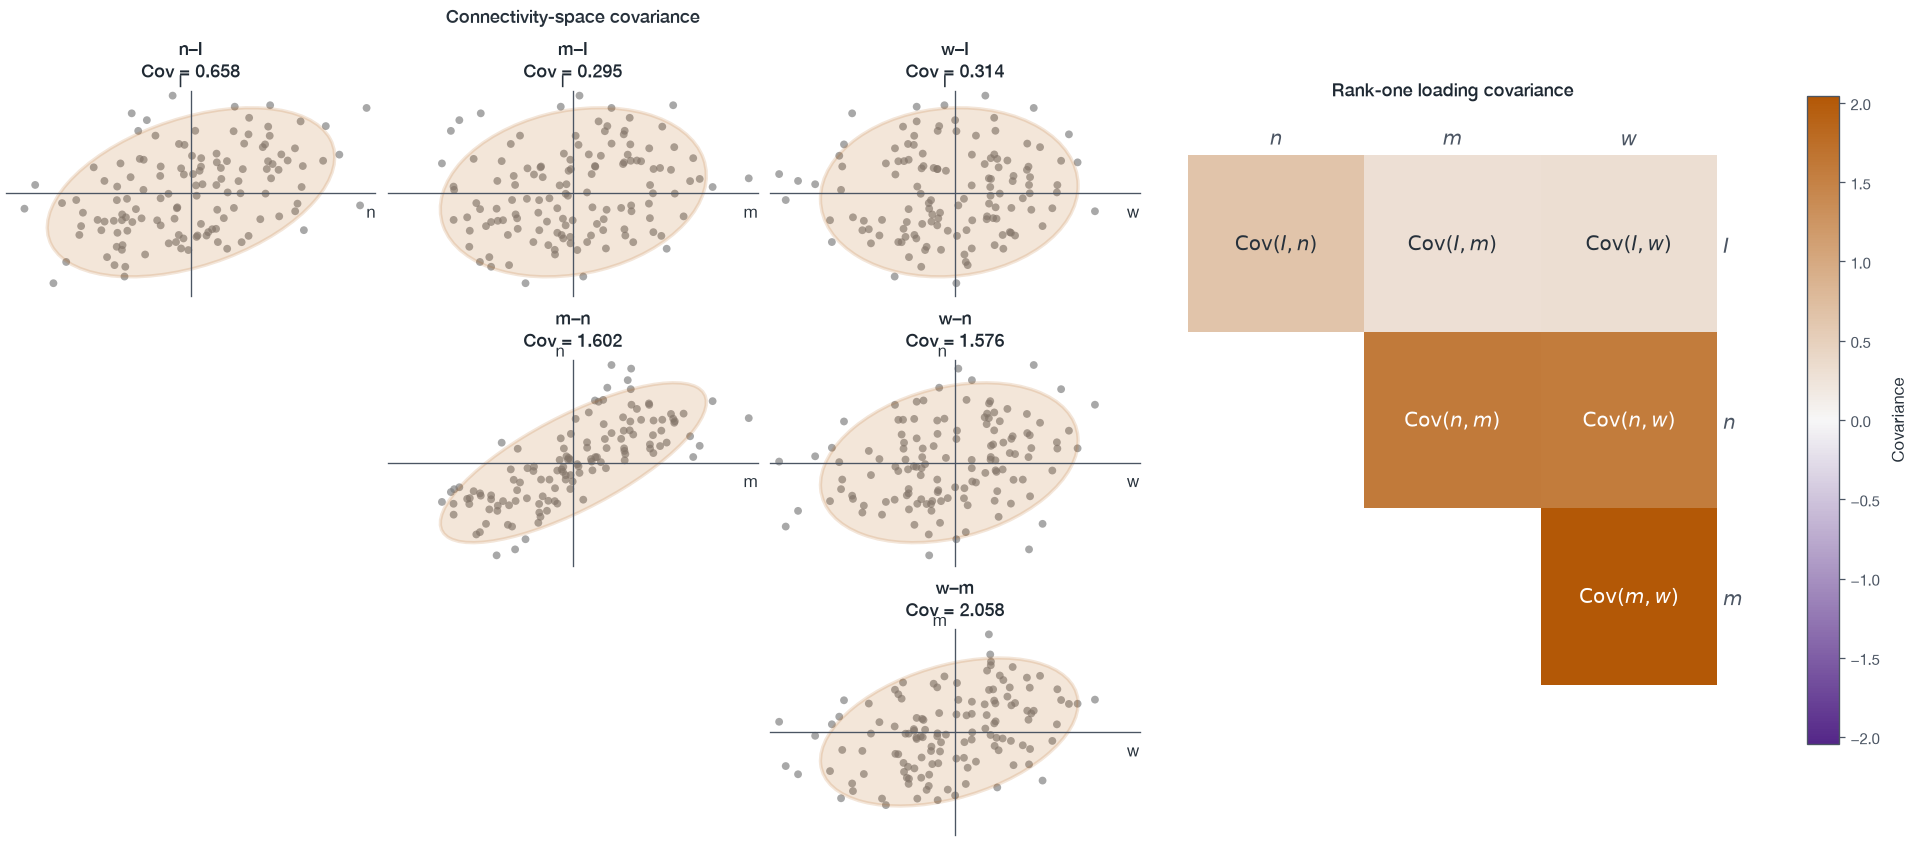

{'Cov(n, I)': 0.6531196302377552,
 'Cov(m, n)': 1.58964165924347,
 'Cov(m, w)': 2.042173281209281}

In [5]:
rank1_vectors = analysis.connectivity_vectors(rank1_model)
rank1_names = tuple(rank1_vectors)
rank1_loading_mean, rank1_loading_covariance = analysis.fit_loading_gaussian(
    rank1_vectors
)

rank1_loading_space_figure, _, _ = plotting.plot_connectivity_summary(
    rank1_vectors,
    rank1_names,
    rank1_loading_covariance,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
    covariance_title="Rank-one loading covariance",
)
save_report_figure(
    rank1_loading_space_figure,
    "rank1-loading-space-covariance.pdf",
)
plt.show()

rank1_couplings = analysis.named_covariances(
    rank1_names,
    rank1_loading_covariance,
    (("n", "I"), ("m", "n"), ("m", "w")),
)
rank1_couplings


### 1.4 Is a four-dimensional Gaussian sufficient?

We fit one multivariate Gaussian to the 128 neuron rows, redraw complete
networks from that distribution, and test them without further training.
Matching a covariance *in expectation* need not give identical finite-\(N\)
behavior, especially near a bifurcation. The three panels below follow the
argument from left to right: a Gaussian draw reproduces the loading
marginals, preserves the covariance structure, and yields sampled networks
that retain the trained network's decision accuracy.

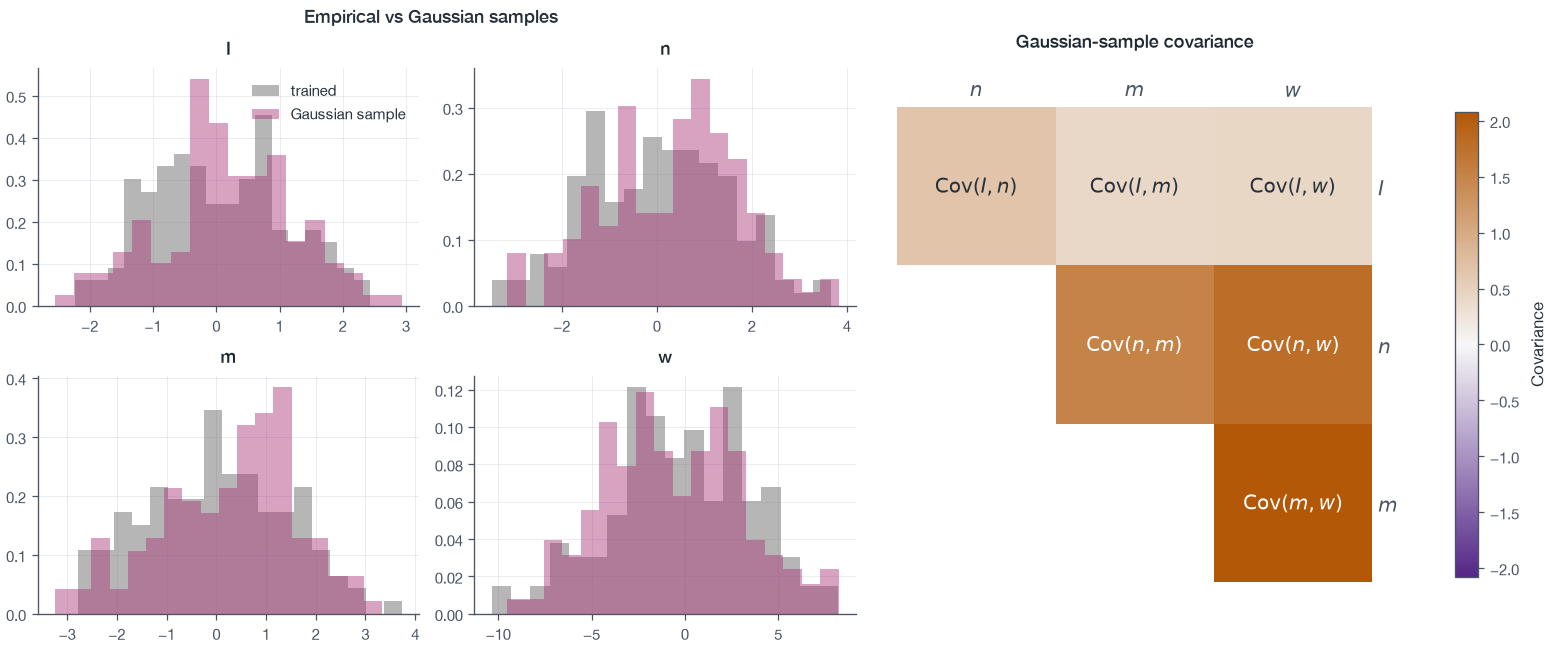

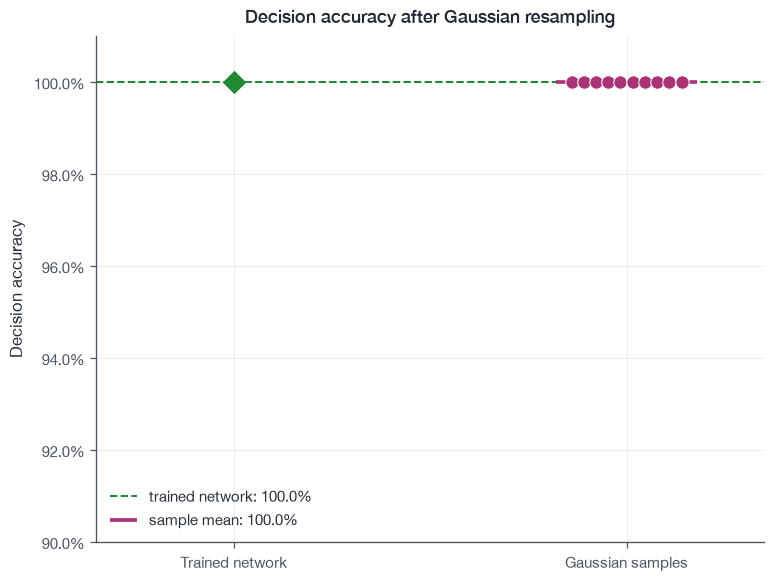

One-sample relative covariance error: 4.2%
Gaussian-network accuracy, mean [range]: 100.0% [100.0%, 100.0%]


In [6]:
rank1_sampled_vectors, rank1_sampled_covariance = (
    analysis.sample_loading_vectors(
        rank1_names,
        rank1_loading_mean,
        rank1_loading_covariance,
        num_samples=NUM_UNITS,
        rng=np.random.default_rng(BASE_SEED + 10),
    )
)
rank1_sampled_networks = analysis.sample_low_rank_rnns(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    num_networks=10,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 11),
)
rank1_sampled_accuracies = np.array(
    [
        decision_accuracy(
            network,
            torch.as_tensor(rank1_test_inputs, dtype=torch.float32),
            torch.as_tensor(rank1_test_labels),
            decision_steps=RANK1_DECISION_STEPS,
        )
        for network in rank1_sampled_networks
    ]
)
rank1_covariance_error = np.linalg.norm(
    rank1_sampled_covariance - rank1_loading_covariance
) / np.linalg.norm(rank1_loading_covariance)

plotting.plot_gaussian_sampling_summary(
    rank1_vectors,
    rank1_sampled_vectors,
    rank1_names,
    rank1_sampled_covariance,
    rank1_accuracy,
    rank1_sampled_accuracies,
    covariance_title="Gaussian-sample covariance",
)
plt.show()

print(f"One-sample relative covariance error: {rank1_covariance_error:.1%}")
print(
    "Gaussian-network accuracy, mean [range]: "
    f"{rank1_sampled_accuracies.mean():.1%} "
    f"[{rank1_sampled_accuracies.min():.1%}, {rank1_sampled_accuracies.max():.1%}]"
)


### 1.5 The population activity is two-dimensional

Starting from \(x(0)=0\), every drive lies in
\(\operatorname{span}\{m,I\}\): recurrence points along \(m\), input points
along \(I\), and leak cannot create a new direction. The trajectories should
therefore move with the stimulus and then separate by choice.

If \(m\) and \(I\) were unknown—as in a generic RNN or neural recording—we
would stack the centered states into a matrix \(X\), form the neuron-by-neuron
covariance \(C=X^\top X/(T-1)\), and diagonalize \(C\). Its eigenvectors are
the principal-component directions and each eigenvalue is the variance along
that direction.

The left panel below asks how many directions are needed. The right panel
projects every selected trial onto the first two covariance eigenvectors.
Repeated paths across trials show that this one PCA plane consistently captures
the population trajectories. PCA may rotate the axes within the plane, so PC1
and PC2 need not equal \(m\) and \(I\) individually. Here the model already tells
us that all states lie in \(\operatorname{span}\{m,I\}\); because the trials explore
two independent directions and PCA finds only two nonzero directions, its plane
is that same subspace. For noisy experimental data, factor analysis can separate
shared low-dimensional activity from neuron-specific noise.

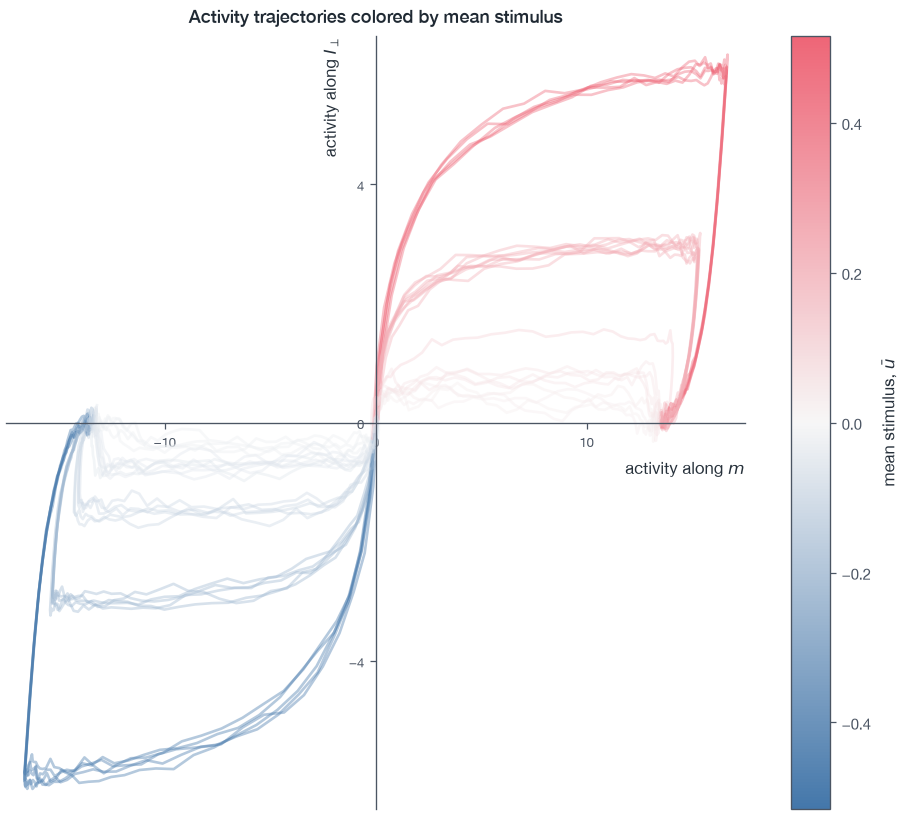

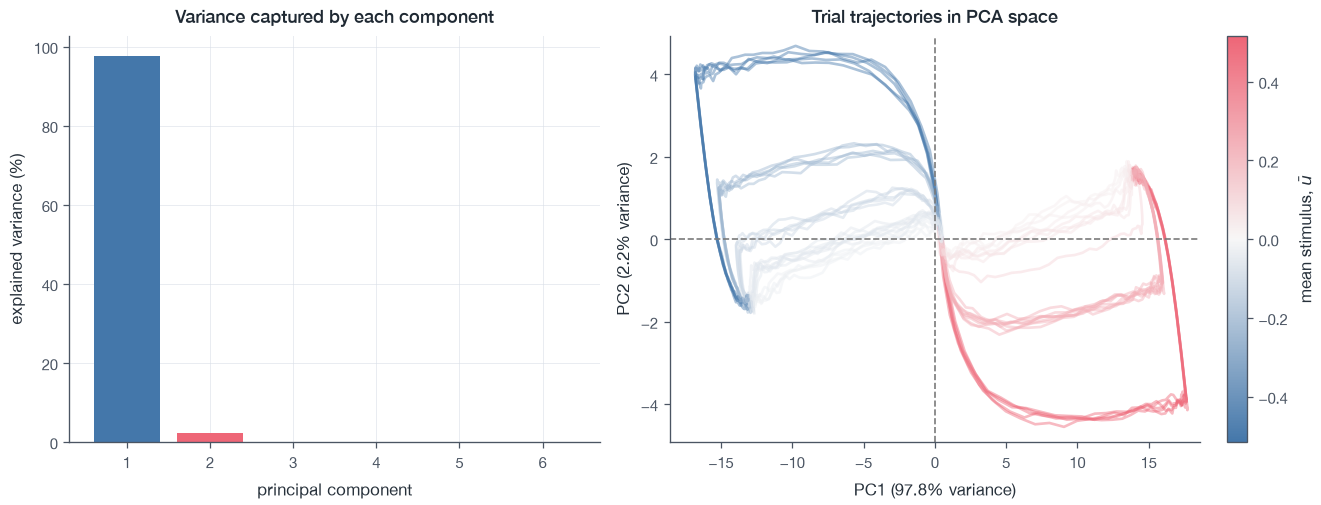

Variance explained by the first two PCs: 100.00%


In [7]:
rank1_projected = analysis.project_rank_one_activity(
    torch.as_tensor(rank1_states, dtype=torch.float32),
    rank1_model,
)
trajectory_subset = np.linspace(0, len(rank1_projected) - 1, 48, dtype=int)
rank1_latent_trajectories_figure, _ = (
    plotting.plot_activity_trajectories_by_stimulus(
        rank1_projected[trajectory_subset],
        stimulus_estimates[trajectory_subset],
    )
)
save_report_figure(
    rank1_latent_trajectories_figure,
    "rank1-latent-trajectories.pdf",
)
plt.show()

(
    rank1_explained_variance,
    rank1_pca_components,
    rank1_pca_trajectories,
) = analysis.principal_component_analysis(rank1_states)
rank1_pca_summary_figure, _ = plotting.plot_pca_summary(
    rank1_explained_variance,
    rank1_pca_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
save_report_figure(
    rank1_pca_summary_figure,
    "rank1-pca-summary.pdf",
)
plt.show()
print(
    "Variance explained by the first two PCs: "
    f"{rank1_explained_variance[:2].sum():.2%}"
)


### 1.6 A rank-generic Gaussian equivalent circuit

For jointly Gaussian loadings and
\(x_i\approx I_i v+\sum_r m_{ir}\kappa_r\), Stein's lemma gives

\[
\dot\kappa
=-\kappa+\mu_n\langle\tanh h\rangle
+\operatorname{Cov}(n,h)\langle\operatorname{sech}^2h\rangle,
\qquad
\dot v=-v+u,
\]

with the analogous expression for \(z\) using \(w\). For zero means and
orthogonal rank-one loadings this reduces to the handout:

\[
\dot\kappa=-\kappa+g(\Delta)
[\sigma_{mn}\kappa+\sigma_{nI}v],
\quad
\Delta^2=\sigma_m^2\kappa^2+\sigma_I^2v^2.
\]

Because the empirical circuit succeeds, we do not substitute the paper values.
If that fallback were needed, the handout leaves \(\sigma_m\) unspecified;
we would state the extra convention \(\sigma_m=1\) rather than guess silently.

The library implementation keeps the full fitted means and covariance, and
works unchanged for rank two.

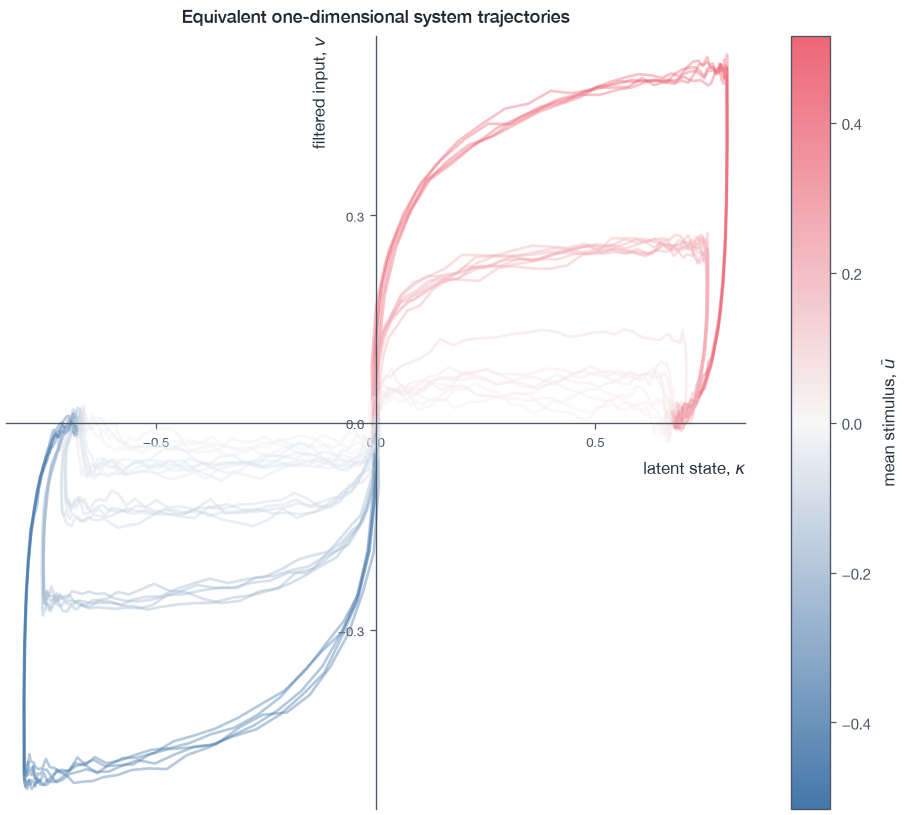

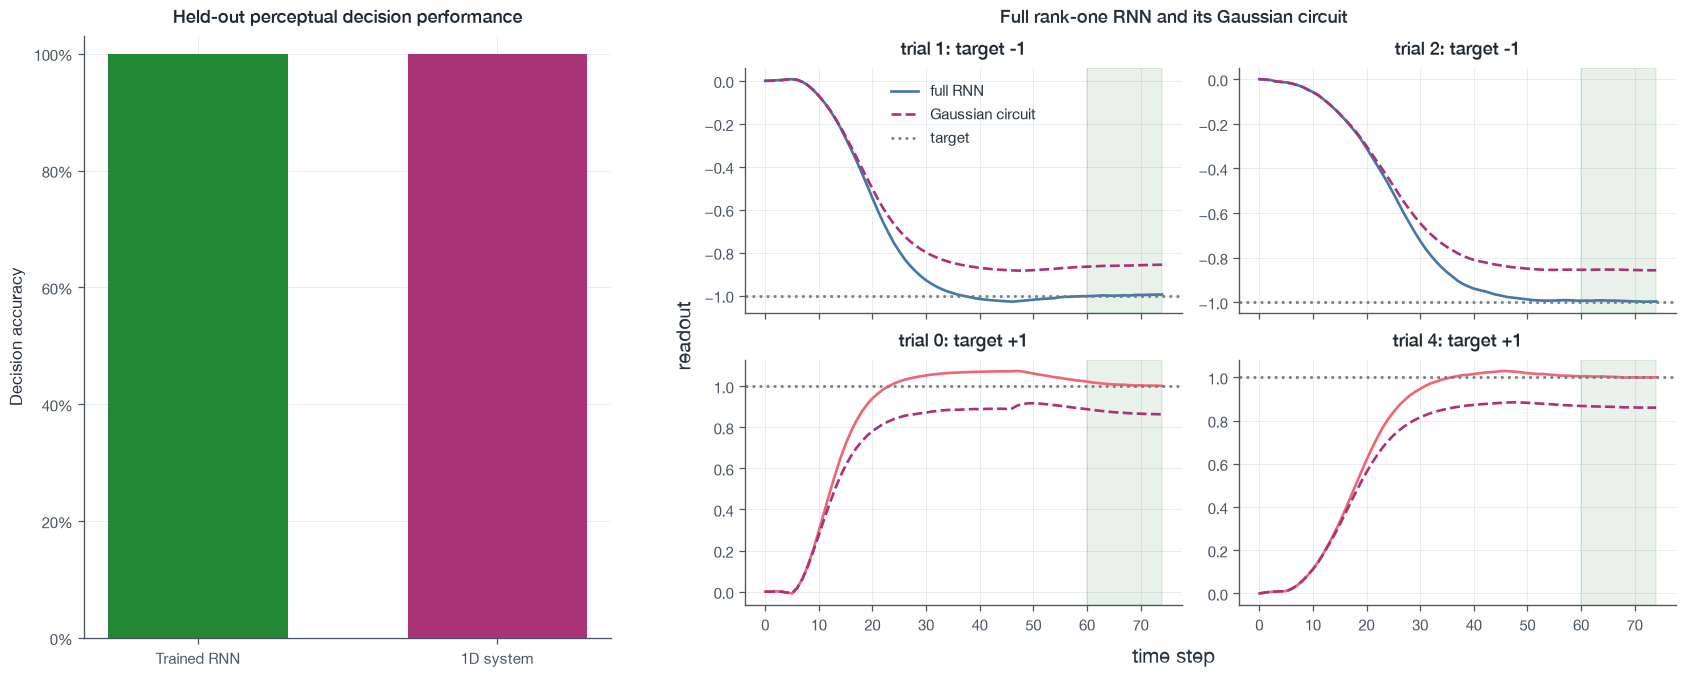

Gaussian-circuit sign accuracy: 100.0%


In [8]:
(
    rank1_reduced_outputs,
    rank1_reduced_kappa,
    rank1_filtered_input,
) = mean_field.simulate_gaussian_circuit(
    rank1_test_inputs,
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    step_size=rank1_model.step_size,
)
rank1_reduced_decisions = analysis.decision_values(
    rank1_reduced_outputs,
    RANK1_DECISION_STEPS,
)
rank1_reduced_accuracy = float(
    np.mean(
        np.where(rank1_reduced_decisions >= 0, 1, -1)
        == rank1_test_labels
    )
)

reduced_trajectories = np.dstack(
    (rank1_reduced_kappa[..., 0], rank1_filtered_input)
)
plotting.plot_reduced_system_trajectories(
    reduced_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()
rank1_reduced_summary_figure = plt.figure(figsize=(14, 5.6), layout="constrained")
accuracy_panel, comparison_panel = rank1_reduced_summary_figure.subfigures(
    1,
    2,
    width_ratios=(1, 1.65),
    wspace=0.06,
)
plotting.plot_reduced_system_accuracy(
    rank1_accuracy,
    rank1_reduced_accuracy,
    axis=accuracy_panel.subplots(),
)
plotting.plot_output_comparison(
    rank1_outputs,
    rank1_reduced_outputs,
    rank1_test_labels,
    rank1_examples,
    decision_steps=RANK1_DECISION_STEPS,
    axes=comparison_panel.subplots(2, 2, sharex=True),
)
plt.show()

print(f"Gaussian-circuit sign accuracy: {rank1_reduced_accuracy:.1%}")


### 1.7 Fixed points reveal a categorical memory

At zero input, define the one-dimensional flow \(f(\kappa)=\dot\kappa\)
and energy \(q(\kappa)=f(\kappa)^2/2\). We minimize \(q\) from every local
basin on a dense grid, verify \(f\approx0\), and classify each root by the
slope \(f'(\kappa)\): negative is stable, positive is unstable.

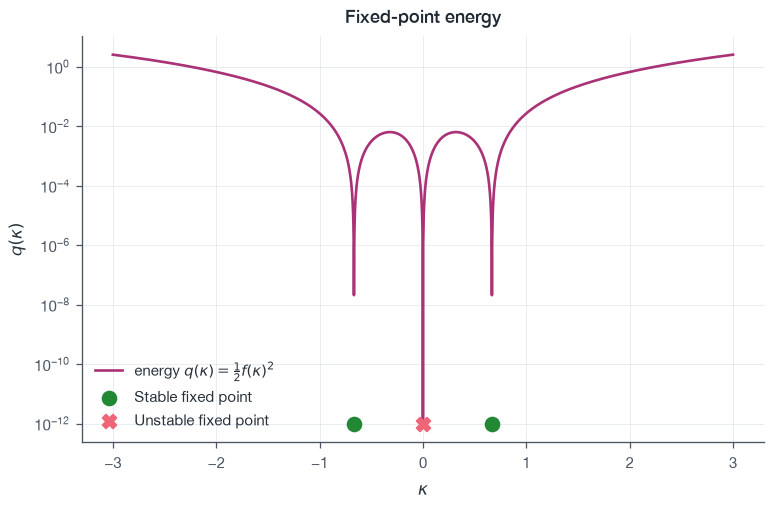

kappa=-0.6671  slope=-0.572  stable
kappa=-0.0000  slope=+0.590  unstable
kappa=+0.6671  slope=-0.572  stable


In [9]:
(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
) = mean_field.rank_one_fixed_points(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)
fixed_point_stability = np.where(
    fixed_point_slopes < 0,
    "stable",
    "unstable",
)
fixed_point_residuals = mean_field.gaussian_latent_flow(
    fixed_points[:, None],
    np.zeros(len(fixed_points)),
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)[:, 0]

plotting.plot_fixed_points(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
)
plt.show()

for point, slope, stability in zip(
    fixed_points,
    fixed_point_slopes,
    fixed_point_stability,
):
    print(f"kappa={point:+.4f}  slope={slope:+.3f}  {stability}")


A sign decision is naturally stored by two stable choice states separated by
an unstable boundary. An exact-value integrator would be qualitatively
different: it needs a continuum of marginal fixed points—a line attractor
with \(f(\kappa)\approx0\) across a range—so every input magnitude, not only
its sign, can persist.

## 2. Rank-two working memory: two solutions

Both networks learn the comparison

\[
y=\frac{f_1-f_2}{24},
\]

but under different timing regimes:

- **Network A** is randomly initialized and trained on one fixed schedule.
- **Network B** is initialized with the handout's persistent/transient
  structure and trained across randomized delays.

We use the same short analysis for each network: verify behavior,
identify the latent dynamics, fit its post-training loading Gaussian,
and compare finite samples with the full-covariance and diagonal
mean-field circuits. Reconstruction scores use each network's native
protocol; section 2.4 then compares the trained networks on identical
trials.

### 2.1 Task and fixed-delay evaluation

The fixed task uses the full \(7\times7\) grid of frequencies from
10 to 34 Hz. The final five time steps form the decision window.


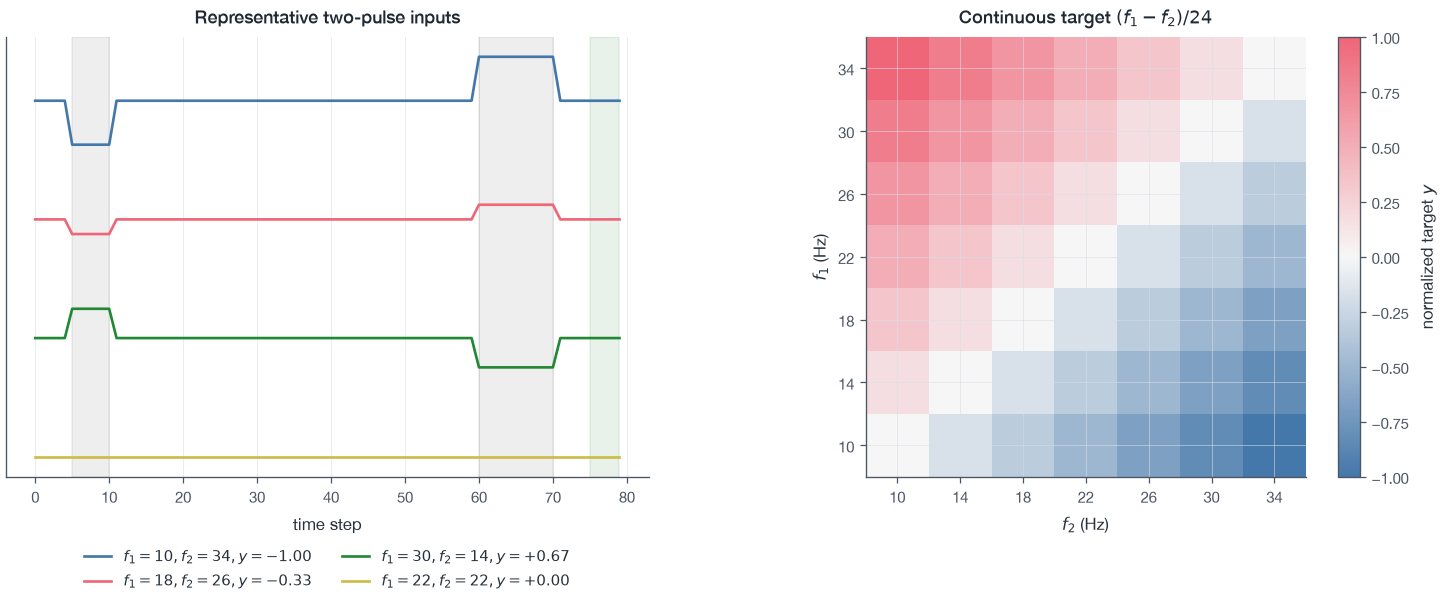

In [10]:
MEMORY_DECISION_STEPS = memory_task.FIXED_DECISION_STEPS
MEMORY_TRIAL_LENGTH = memory_task.FIXED_TRIAL_STEPS
memory_grid_pairs = memory_task.frequency_pair_grid()
memory_grid_inputs, memory_grid_targets = memory_task.make_fixed_delay_trials(
    memory_grid_pairs
)
target_matrix = memory_grid_targets.reshape(
    len(memory_task.FREQUENCIES),
    len(memory_task.FREQUENCIES),
)

outside_stimuli = np.ones(MEMORY_TRIAL_LENGTH, dtype=bool)
for start, stop in (
    memory_task.FIXED_FIRST_WINDOW,
    memory_task.FIXED_SECOND_WINDOW,
):
    outside_stimuli[start:stop] = False
assert memory_grid_inputs.shape == (49, MEMORY_TRIAL_LENGTH)
assert np.all(memory_grid_inputs[:, outside_stimuli] == 0)

example_pairs = np.array(((10, 34), (18, 26), (30, 14), (22, 22)))
example_inputs, example_targets = memory_task.make_fixed_delay_trials(
    example_pairs
)
plotting.plot_memory_trials(
    example_pairs,
    example_inputs,
    example_targets,
    target_matrix,
    memory_task.FREQUENCIES,
    first_window=memory_task.FIXED_FIRST_WINDOW,
    second_window=memory_task.FIXED_SECOND_WINDOW,
    decision_steps=MEMORY_DECISION_STEPS,
)
plt.show()


### 2.2 Network A: a fixed-delay rotation

#### Train and verify

We train rank-two and rank-one networks on the same fixed-delay trials.
The rank-one model is a capacity control; only the rank-two network
reaches the task criterion on the complete frequency grid.


In [11]:
MEMORY_TRAIN_TRIALS = 200
MEMORY_RANK2_EPOCHS = 600
MEMORY_RANK1_EPOCHS = 600

_, memory_train_inputs, memory_train_targets = (
    memory_task.sample_fixed_delay_trials(
        MEMORY_TRAIN_TRIALS,
        rng=np.random.default_rng(BASE_SEED),
    )
)

torch.manual_seed(BASE_SEED)
oscillatory_model = LowRankRNN(NUM_UNITS, rank=2)
oscillatory_losses = train_model(
    oscillatory_model,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK2_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=200,
)

torch.manual_seed(BASE_SEED + 1)
fixed_rank1_control = LowRankRNN(NUM_UNITS, rank=1)
fixed_rank1_losses = train_model(
    fixed_rank1_control,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=None,
)

oscillatory_grid_outputs, _ = analysis.run_model(
    oscillatory_model,
    memory_grid_inputs,
)
oscillatory_grid_decisions = analysis.decision_values(
    oscillatory_grid_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_mse, _ = analysis.regression_metrics(
    oscillatory_grid_decisions,
    memory_grid_targets,
)

fixed_rank1_outputs, _ = analysis.run_model(
    fixed_rank1_control,
    memory_grid_inputs,
)
fixed_rank1_decisions = analysis.decision_values(
    fixed_rank1_outputs,
    MEMORY_DECISION_STEPS,
)
fixed_rank1_mse, _ = analysis.regression_metrics(
    fixed_rank1_decisions,
    memory_grid_targets,
)

assert oscillatory_mse < TASK_MSE_THRESHOLD
print(f"Network A rank-two MSE: {oscillatory_mse:.6f}")
print(f"Matched rank-one MSE:   {fixed_rank1_mse:.6f}")


Epoch 200: loss=0.115002


Epoch 400: loss=0.004609


Epoch 600: loss=0.000548


Network A rank-two MSE: 0.000788
Matched rank-one MSE:   0.112504


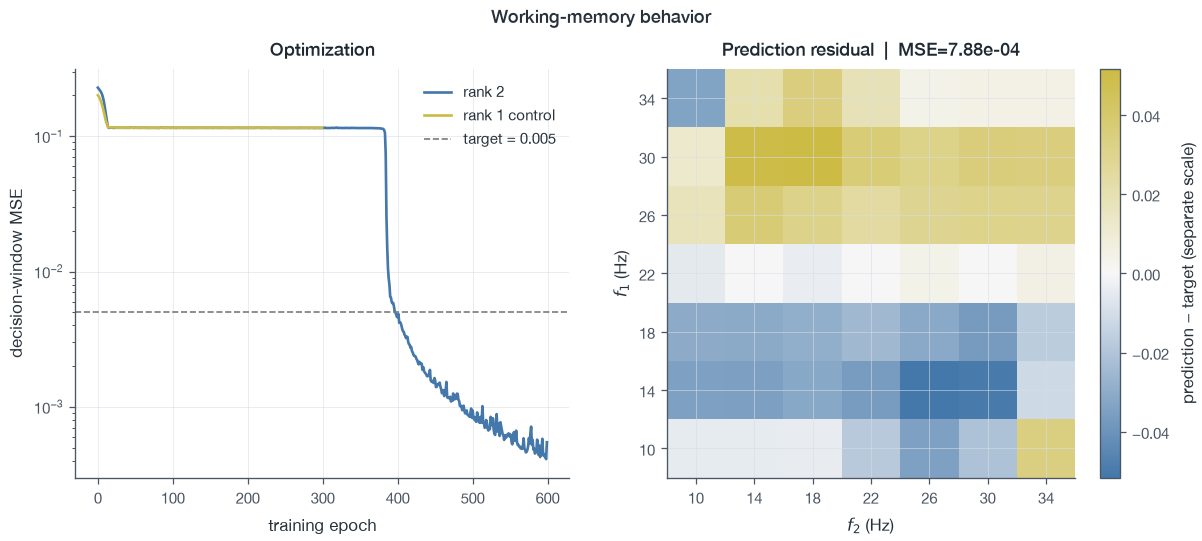

In [12]:
plotting.plot_memory_behavior(
    oscillatory_losses,
    fixed_rank1_losses,
    target_matrix,
    oscillatory_grid_decisions,
    memory_task.FREQUENCIES,
    mse=oscillatory_mse,
    loss_threshold=TASK_MSE_THRESHOLD,
)
plt.show()


#### Identify the dynamics

We place Network A in the library's SVD basis, which preserves
\(MN^\top\), then inspect its recurrent eigenvalues and projected
trajectories.


In [13]:
oscillatory_canonical, oscillatory_reconstruction_error = (
    analysis.svd_canonical_model(oscillatory_model)
)
oscillatory_m = oscillatory_canonical.m.detach().numpy()
oscillatory_n = oscillatory_canonical.n.detach().numpy()
oscillatory_overlap_eigenvalues = np.linalg.eigvals(
    analysis.connectivity_overlap(oscillatory_m, oscillatory_n)
)

assert oscillatory_reconstruction_error < 1e-5
print(
    "Recurrent overlap eigenvalues:",
    np.round(oscillatory_overlap_eigenvalues, 3),
)


Recurrent overlap eigenvalues: [0.989+0.223j 0.989-0.223j]


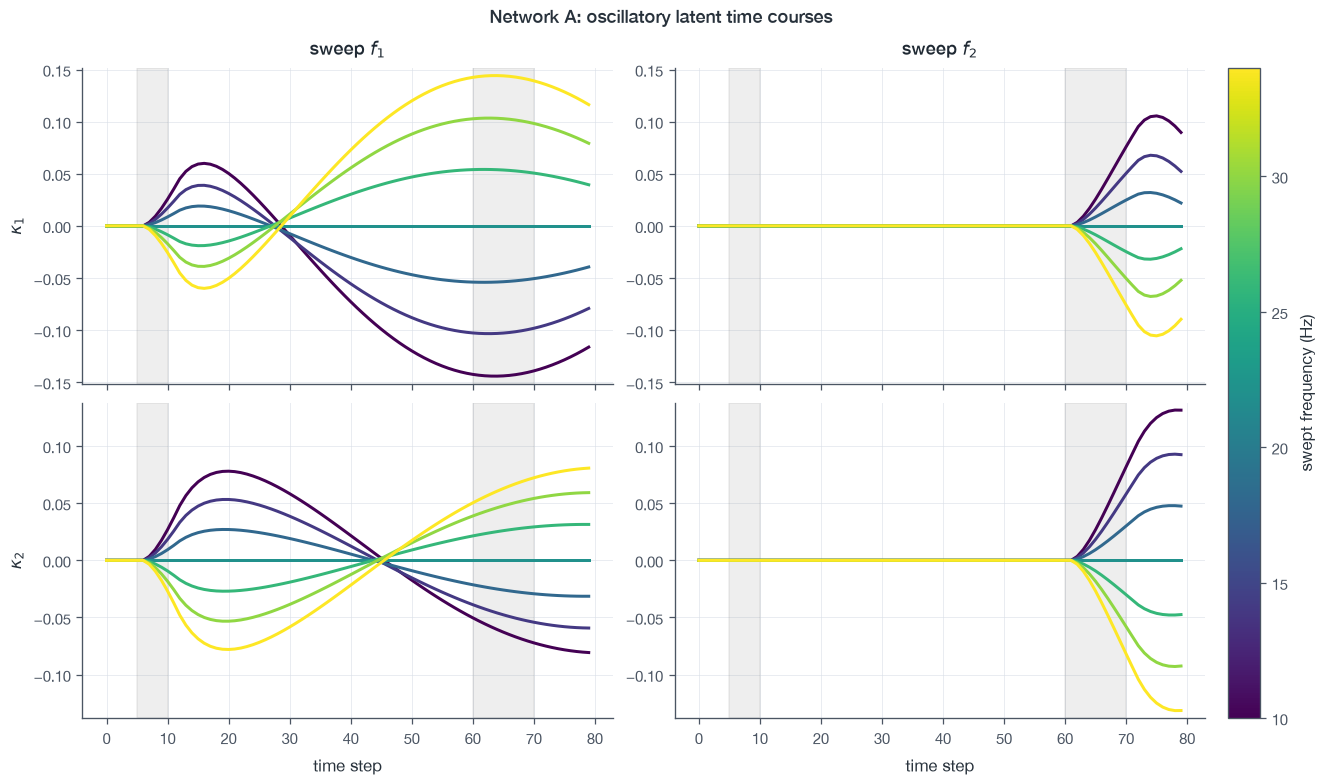

In [14]:
first_sweep_pairs, second_sweep_pairs = memory_task.frequency_sweeps()
first_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    first_sweep_pairs
)
second_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    second_sweep_pairs
)
oscillatory_basis = np.column_stack(
    (oscillatory_m, oscillatory_canonical.I.detach().numpy())
)
_, first_sweep_states, first_sweep_coordinates = (
    analysis.simulate_and_project(
        oscillatory_canonical,
        first_sweep_inputs,
        oscillatory_basis,
    )
)
_, _, second_sweep_coordinates = analysis.simulate_and_project(
    oscillatory_canonical,
    second_sweep_inputs,
    oscillatory_basis,
)

plotting.plot_latent_sweeps(
    first_sweep_coordinates[..., :2],
    second_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=np.arange(MEMORY_TRIAL_LENGTH),
    window_spans=(
        (
            memory_task.FIXED_FIRST_WINDOW[0],
            memory_task.FIXED_FIRST_WINDOW[1] - 1,
        ),
        (
            memory_task.FIXED_SECOND_WINDOW[0],
            memory_task.FIXED_SECOND_WINDOW[1] - 1,
        ),
    ),
    column_titles=(r"sweep $f_1$", r"sweep $f_2$"),
    row_labels=(r"$\kappa_1$", r"$\kappa_2$"),
    title="Network A: oscillatory latent time courses",
)
plt.show()


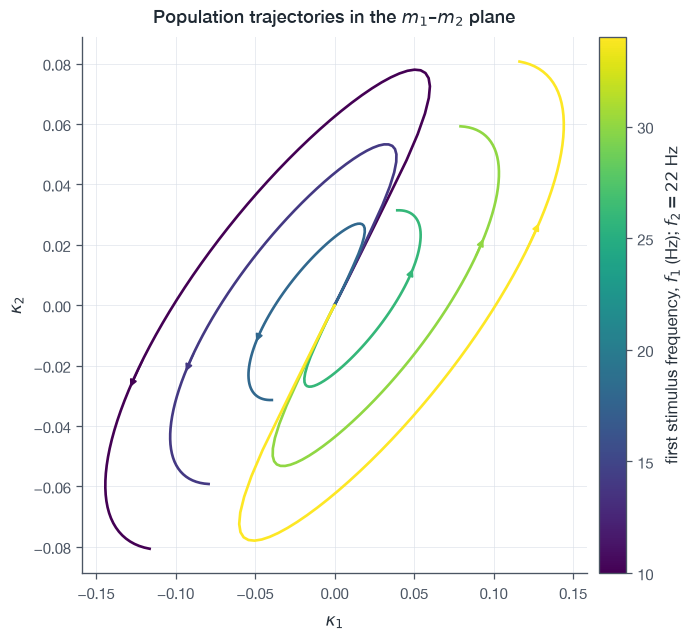

Median delay-flow eigenvalues (1/tau): [-0.021 -0.021]


In [15]:
plotting.plot_latent_plane(
    first_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    colorbar_label=(
        r"first stimulus frequency, $f_1$ (Hz); $f_2=22$ Hz"
    ),
)
plt.show()

delay_probe_states = first_sweep_states[
    :, memory_task.FIXED_SECOND_WINDOW[0] - 1
]
delay_eigenvalues = analysis.latent_jacobian_eigenvalues(
    oscillatory_canonical,
    delay_probe_states,
)
median_delay_decay = np.median(
    np.sort(delay_eigenvalues.real, axis=1),
    axis=0,
)[::-1]
print(
    "Median delay-flow eigenvalues (1/tau):",
    np.round(median_delay_decay, 3),
)


The out-of-phase \(\kappa_1\) and \(\kappa_2\) traces, complex conjugate
overlap modes, slow local decay, and curved phase portrait all point to
the same mechanism: Network A uses a slowly decaying rotation as a clock
for the fixed schedule.


#### Reconstruct from the post-training Gaussian

We fit one six-dimensional Gaussian in the SVD basis and reuse it for
all three tests: finite \(N=128\) networks, the full-covariance
mean-field circuit, and the stricter diagonal circuit. All are scored
on Network A's fixed-delay grid.


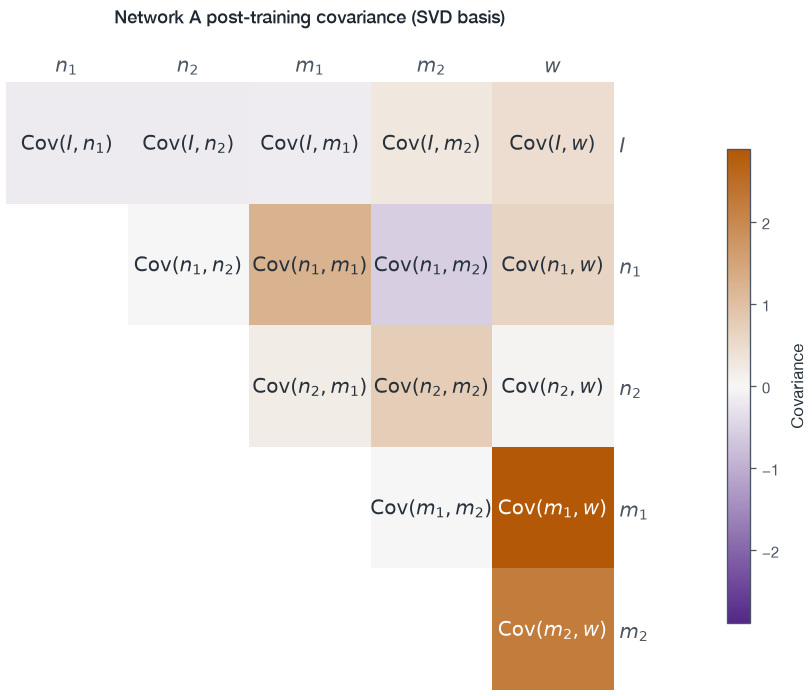

In [16]:
oscillatory_vectors = analysis.connectivity_vectors(
    oscillatory_canonical
)
oscillatory_names = tuple(oscillatory_vectors)
(
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
) = analysis.fit_loading_gaussian(oscillatory_vectors)

plotting.plot_connectivity_covariance(
    oscillatory_names,
    oscillatory_loading_covariance,
    title="Network A post-training covariance (SVD basis)",
)
plt.show()


In [17]:
oscillatory_sampled_networks = analysis.sample_low_rank_rnns(
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 21),
)
oscillatory_sampled_mses = analysis.network_regression_mses(
    oscillatory_sampled_networks,
    memory_grid_inputs,
    memory_grid_targets,
    decision_steps=MEMORY_DECISION_STEPS,
)

print(
    "Finite Gaussian RNN MSE, median [range]: "
    f"{np.median(oscillatory_sampled_mses):.4f} "
    f"[{oscillatory_sampled_mses.min():.4f}, "
    f"{oscillatory_sampled_mses.max():.4f}]"
)


Finite Gaussian RNN MSE, median [range]: 0.5013 [0.0882, 3.2224]


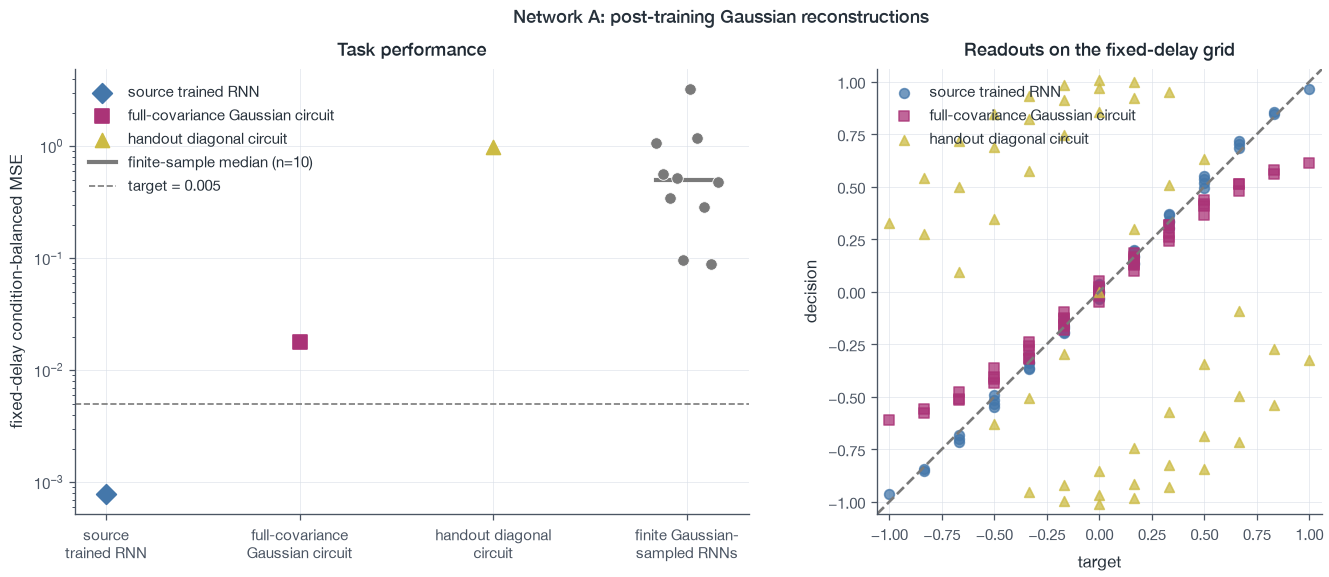

Source / full / diagonal MSE: [7.88000e-04 1.80290e-02 9.84745e-01]


In [18]:
oscillatory_reduced_outputs, _, _ = mean_field.simulate_gaussian_circuit(
    memory_grid_inputs,
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
oscillatory_reduced_decisions = analysis.decision_values(
    oscillatory_reduced_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_reduced_mse, _ = (
    analysis.regression_metrics(
        oscillatory_reduced_decisions,
        memory_grid_targets,
    )
)

oscillatory_diagonal_outputs, _, _ = (
    mean_field.simulate_diagonal_circuit(
        memory_grid_inputs,
        oscillatory_names,
        oscillatory_loading_covariance,
        step_size=oscillatory_canonical.step_size,
    )
)
oscillatory_diagonal_decisions = analysis.decision_values(
    oscillatory_diagonal_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_diagonal_mse, _ = (
    analysis.regression_metrics(
        oscillatory_diagonal_decisions,
        memory_grid_targets,
    )
)

plotting.plot_gaussian_pipeline(
    oscillatory_mse,
    oscillatory_reduced_mse,
    oscillatory_diagonal_mse,
    oscillatory_sampled_mses,
    memory_grid_targets,
    oscillatory_grid_decisions,
    oscillatory_reduced_decisions,
    oscillatory_diagonal_decisions,
    threshold=TASK_MSE_THRESHOLD,
    title="Network A: post-training Gaussian reconstructions",
    score_label="fixed-delay condition-balanced MSE",
    readout_title="Readouts on the fixed-delay grid",
)
plt.show()

print(
    "Source / full / diagonal MSE:",
    np.round(
        (
            oscillatory_mse,
            oscillatory_reduced_mse,
            oscillatory_diagonal_mse,
        ),
        6,
    ),
)


Network A solves the task, but its fitted Gaussian is fragile at
finite \(N\). The full-covariance circuit is much closer to the
trained network than the diagonal circuit, whose missing cross-mode
terms remove the rotation.


### 2.3 Network B: persistent and transient modes

Network B starts from the handout's structured loading relations and
trains on dense frequencies with randomized 500–2000 ms delays. The
handout coefficients only initialize training; every reconstruction
below uses the trained network's fitted loading statistics.

#### Train and verify


In [19]:
PERSISTENT_TRANSIENT_SEED = 2032
PERSISTENT_TRANSIENT_EPOCHS = 12
DENSE_FREQUENCIES = np.arange(10, 35)
DELAY_CURRICULUM = (
    np.arange(25, 51),
    np.arange(25, 76),
    np.arange(25, 101),
)

persistent_model = persistent_transient_rnn(
    NUM_UNITS,
    seed=PERSISTENT_TRANSIENT_SEED,
)
persistent_losses = train_variable_delay(
    persistent_model,
    DELAY_CURRICULUM,
    rng=np.random.default_rng(PERSISTENT_TRANSIENT_SEED),
    frequencies=DENSE_FREQUENCIES,
    num_trials=640,
    epochs_per_stage=PERSISTENT_TRANSIENT_EPOCHS,
    batch_size=32,
    learning_rate=5e-3,
    max_gradient_norm=1.0,
)

print(f"Final training MSE: {persistent_losses[-1]:.4g}")


Final training MSE: 0.002075


In [20]:
probe_delays = np.array((25, 50, 75, 100))
(
    persistent_probe_mses,
    _,
    persistent_probe_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: analysis.run_model(persistent_model, inputs)[0],
    memory_grid_pairs,
    probe_delays,
)

assert persistent_probe_mses.max() < TASK_MSE_THRESHOLD
print(
    "Decision MSE at 500, 1000, 1500, 2000 ms:",
    np.round(persistent_probe_mses, 4),
)


Decision MSE at 500, 1000, 1500, 2000 ms: [0.0016 0.0018 0.0021 0.0024]


#### Identify the dynamics

The library's real-mode basis orders the recurrent modes from slowest
to fastest. We expect one near-persistent mode and one strongly
contracting mode.


In [21]:
persistent_m, persistent_n, persistent_overlap_values = (
    analysis.real_overlap_modes(persistent_model)
)
persistent_overlap = analysis.connectivity_overlap(
    persistent_m,
    persistent_n,
)

print("Loop gains:", np.round(persistent_overlap_values, 3))
print(
    "Zero-state flow eigenvalues (1/tau):",
    np.round(persistent_overlap_values - 1, 3),
)


Loop gains: [ 1.011 -0.218]
Zero-state flow eigenvalues (1/tau): [ 0.011 -1.218]


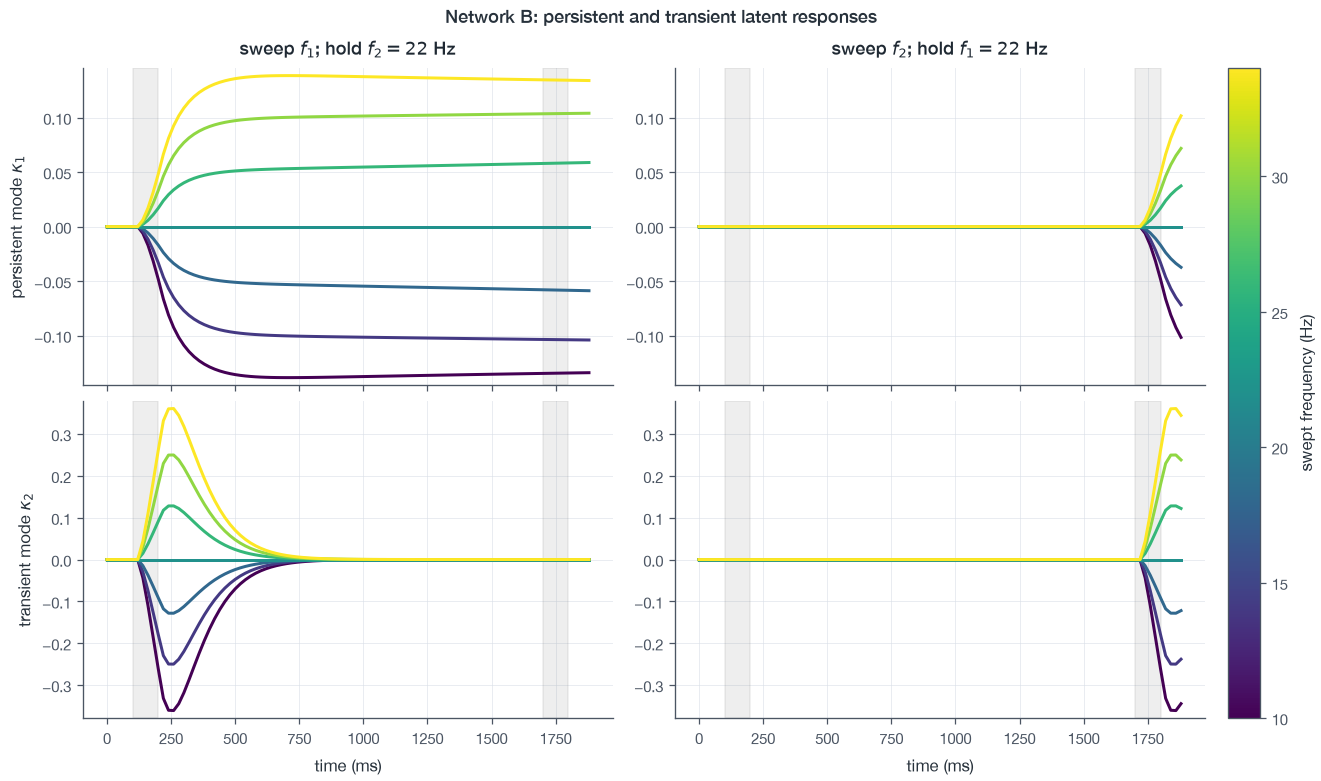

In [22]:
persistent_delay = 75
first_frequency_sweep, second_frequency_sweep = (
    memory_task.frequency_sweeps()
)
first_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    first_frequency_sweep,
    np.full(len(first_frequency_sweep), persistent_delay),
)
second_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    second_frequency_sweep,
    np.full(len(second_frequency_sweep), persistent_delay),
)
persistent_basis = np.column_stack(
    (persistent_m, persistent_model.I.detach().numpy())
)
_, _, first_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    first_mode_inputs,
    persistent_basis,
)
_, _, second_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    second_mode_inputs,
    persistent_basis,
)

second_start = (
    memory_task.VARIABLE_FIXATION_STEPS
    + memory_task.VARIABLE_STIMULUS_STEPS
    + persistent_delay
)
second_stop = second_start + memory_task.VARIABLE_STIMULUS_STEPS
plotting.plot_latent_sweeps(
    first_mode_coordinates[..., :2],
    second_mode_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=20 * np.arange(second_stop + 5),
    window_spans=(
        (
            20 * memory_task.VARIABLE_FIXATION_STEPS,
            20
            * (
                memory_task.VARIABLE_FIXATION_STEPS
                + memory_task.VARIABLE_STIMULUS_STEPS
            ),
        ),
        (20 * second_start, 20 * second_stop),
    ),
    column_titles=(
        r"sweep $f_1$; hold $f_2=22$ Hz",
        r"sweep $f_2$; hold $f_1=22$ Hz",
    ),
    row_labels=(
        r"persistent mode $\kappa_1$",
        r"transient mode $\kappa_2$",
    ),
    title="Network B: persistent and transient latent responses",
)
plt.show()


The first mode stores the earlier stimulus through the delay; the
second responds to the later stimulus and contracts quickly. This
gives Network B a delay-robust comparison without tracking phase.


#### Reconstruct from the post-training Gaussian

We now repeat Network A's three reconstruction tests in Network B's
real-mode basis. Scores are reported at 500, 1000, 1500, and 2000 ms;
the comparison plot uses the worst of those delays.


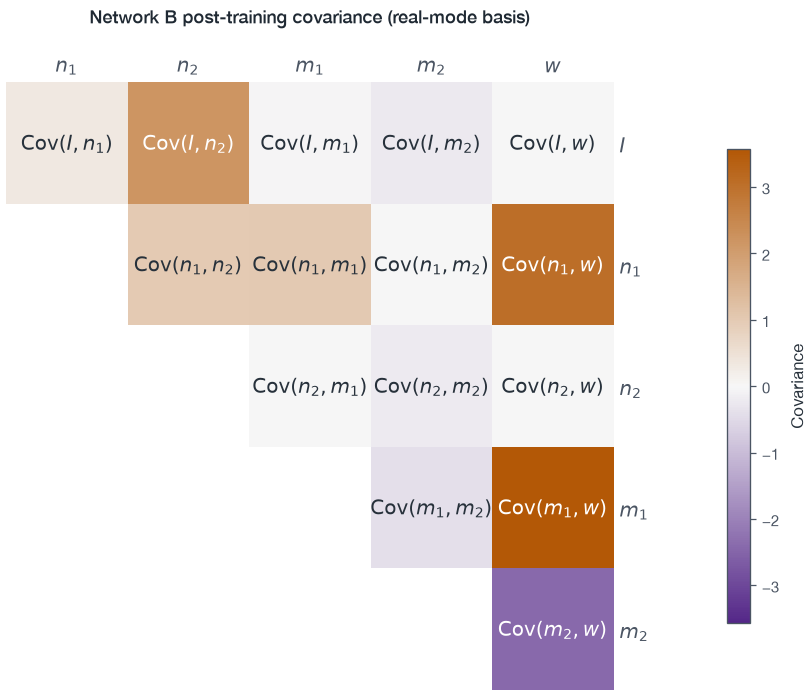

{'Cov(n_1, I)': 0.311437669492754,
 'Cov(n_2, I)': 2.201569257703108,
 'Cov(m_1, w)': 3.5696985450570327,
 'Cov(m_2, w)': -2.4073758300361114}

In [23]:
persistent_vectors = analysis.connectivity_vectors(
    persistent_model,
    m=persistent_m,
    n=persistent_n,
)
persistent_names = tuple(persistent_vectors)
(
    persistent_loading_mean,
    persistent_loading_covariance,
) = analysis.fit_loading_gaussian(persistent_vectors)

plotting.plot_connectivity_covariance(
    persistent_names,
    persistent_loading_covariance,
    title="Network B post-training covariance (real-mode basis)",
)
plt.show()

persistent_couplings = analysis.named_covariances(
    persistent_names,
    persistent_loading_covariance,
    (
        ("n_1", "I"),
        ("n_2", "I"),
        ("m_1", "w"),
        ("m_2", "w"),
    ),
)
persistent_couplings


In [24]:
persistent_sampled_networks = analysis.sample_low_rank_rnns(
    persistent_names,
    persistent_loading_mean,
    persistent_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 31),
)
persistent_sampled_mses_by_delay = np.array(
    [
        analysis.variable_delay_mses(
            network,
            memory_grid_pairs,
            probe_delays,
        )
        for network in persistent_sampled_networks
    ]
)
persistent_sampled_worst_mses = (
    persistent_sampled_mses_by_delay.max(axis=1)
)

print(
    "Finite Gaussian RNN worst-delay MSE, median [range]: "
    f"{np.median(persistent_sampled_worst_mses):.4f} "
    f"[{persistent_sampled_worst_mses.min():.4f}, "
    f"{persistent_sampled_worst_mses.max():.4f}]"
)


Finite Gaussian RNN worst-delay MSE, median [range]: 0.1040 [0.0162, 1.1793]


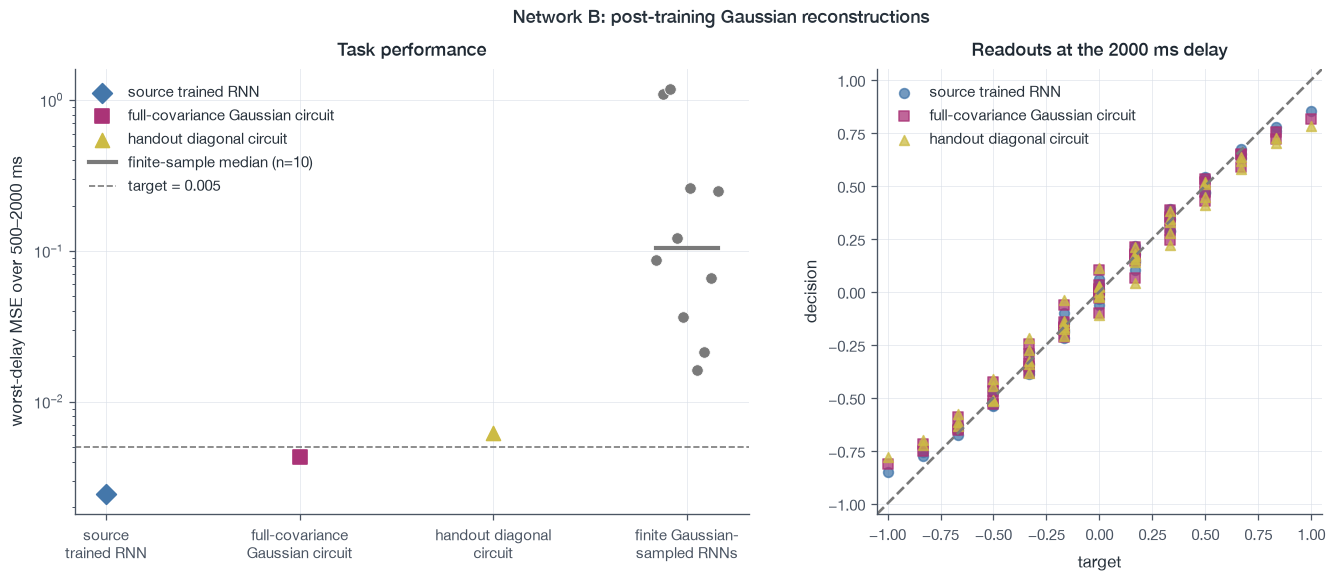

Source MSE by delay:   [0.001622 0.001765 0.002086 0.002446]
Full circuit by delay: [0.002938 0.003229 0.003779 0.004325]
Diagonal by delay:     [0.00534  0.005379 0.005776 0.006172]


In [25]:
(
    persistent_reduced_mses,
    _,
    persistent_reduced_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: mean_field.simulate_gaussian_circuit(
        inputs,
        persistent_names,
        persistent_loading_mean,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )[0],
    memory_grid_pairs,
    probe_delays,
)
(
    persistent_diagonal_mses,
    _,
    persistent_diagonal_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: mean_field.simulate_diagonal_circuit(
        inputs,
        persistent_names,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )[0],
    memory_grid_pairs,
    probe_delays,
)

plotting.plot_gaussian_pipeline(
    persistent_probe_mses.max(),
    persistent_reduced_mses.max(),
    persistent_diagonal_mses.max(),
    persistent_sampled_worst_mses,
    memory_grid_targets,
    persistent_probe_decisions_by_delay[-1],
    persistent_reduced_decisions_by_delay[-1],
    persistent_diagonal_decisions_by_delay[-1],
    threshold=TASK_MSE_THRESHOLD,
    title="Network B: post-training Gaussian reconstructions",
    score_label="worst-delay MSE over 500–2000 ms",
    readout_title="Readouts at the 2000 ms delay",
)
plt.show()

assert persistent_reduced_mses.max() < TASK_MSE_THRESHOLD
print("Source MSE by delay:  ", np.round(persistent_probe_mses, 6))
print("Full circuit by delay:", np.round(persistent_reduced_mses, 6))
print("Diagonal by delay:    ", np.round(persistent_diagonal_mses, 6))


The trained network and full-covariance circuit meet criterion at
every reported delay. The diagonal circuit remains qualitatively
faithful but just misses the strict threshold, while finite Gaussian
networks are again much less reliable.


### 2.4 Direct behavioral comparison

Native reconstruction scores answer whether each fitted Gaussian
preserves its own source network. To compare the trained networks
directly, we now give both models the same 49 frequency pairs and the
same decision windows on A's fixed schedule and across every 20 ms
delay from 500 to 2000 ms.


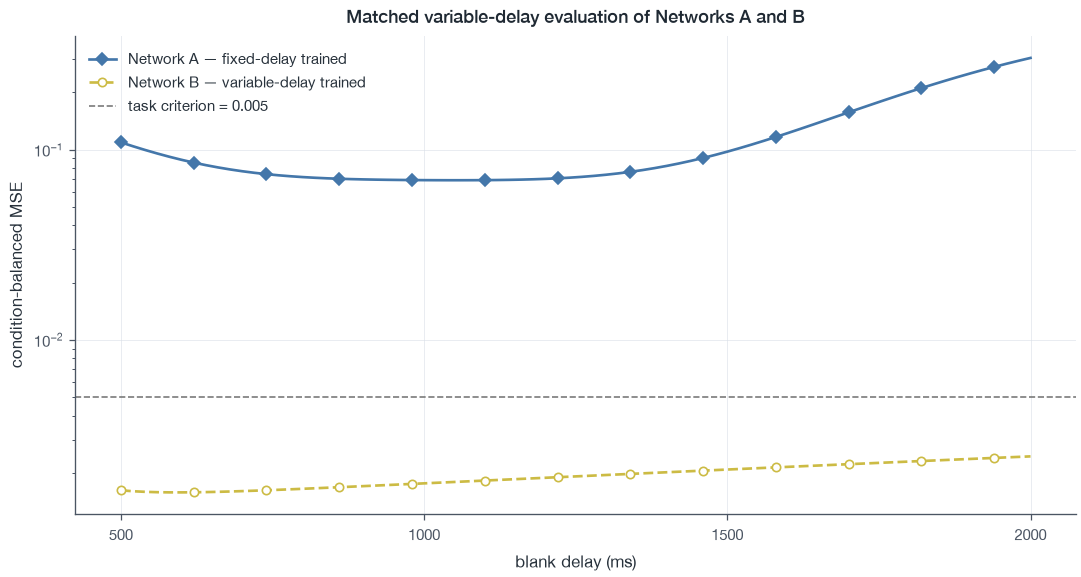

Fixed schedule MSE, A / B: 0.000788 / 0.058812
Variable-delay mean / worst MSE, A: 0.114628 / 0.303430
Variable-delay mean / worst MSE, B: 0.001945 / 0.002446


In [26]:
persistent_fixed_outputs, _ = analysis.run_model(
    persistent_model,
    memory_grid_inputs,
)
persistent_fixed_decisions = analysis.decision_values(
    persistent_fixed_outputs,
    MEMORY_DECISION_STEPS,
)
persistent_fixed_mse, _ = analysis.regression_metrics(
    persistent_fixed_decisions,
    memory_grid_targets,
)

MATCHED_DELAYS = memory_task.DELAYS.copy()
matched_delay_ms = 20 * MATCHED_DELAYS
matched_variable_a_mses = analysis.variable_delay_mses(
    oscillatory_model,
    memory_grid_pairs,
    MATCHED_DELAYS,
)
matched_variable_b_mses = analysis.variable_delay_mses(
    persistent_model,
    memory_grid_pairs,
    MATCHED_DELAYS,
)
matched_probe_indices = probe_delays - MATCHED_DELAYS[0]

assert np.allclose(
    matched_variable_b_mses[matched_probe_indices],
    persistent_probe_mses,
)
plotting.plot_matched_network_comparison(
    matched_delay_ms,
    matched_variable_a_mses,
    matched_variable_b_mses,
    threshold=TASK_MSE_THRESHOLD,
)
plt.show()

print(
    "Fixed schedule MSE, A / B:",
    f"{oscillatory_mse:.6f} / {persistent_fixed_mse:.6f}",
)
print(
    "Variable-delay mean / worst MSE, A:",
    f"{matched_variable_a_mses.mean():.6f} / "
    f"{matched_variable_a_mses.max():.6f}",
)
print(
    "Variable-delay mean / worst MSE, B:",
    f"{matched_variable_b_mses.mean():.6f} / "
    f"{matched_variable_b_mses.max():.6f}",
)


Network A is specialized to its fixed clock. Network B is worse on
that exact schedule, which uses stimulus windows it never saw, but it
stays below criterion throughout the matched variable-delay sweep.
This supports a robustness comparison, not a causal claim about
initialization: the two training protocols differ in more than timing.


### 2.5 Section summary

The reconstruction scores below use each network's native protocol,
so they measure fidelity within a pipeline. The matched plot above is
the direct behavioral comparison.


In [27]:
oscillatory_sample_successes = np.sum(
    oscillatory_sampled_mses < TASK_MSE_THRESHOLD
)
persistent_sample_successes = np.sum(
    persistent_sampled_worst_mses < TASK_MSE_THRESHOLD
)

rank_two_summary = f'''
| Network | Learned dynamics | Source RNN | Finite Gaussian RNNs | Full circuit | Diagonal circuit |
|---|---|---:|---:|---:|---:|
| A | fixed-delay rotation | {oscillatory_mse:.4f} | median {np.median(oscillatory_sampled_mses):.3f}; {oscillatory_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | {oscillatory_reduced_mse:.4f} | {oscillatory_diagonal_mse:.4f} |
| B | persistent / transient modes | worst {persistent_probe_mses.max():.4f} | median worst {np.median(persistent_sampled_worst_mses):.3f}; {persistent_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | worst {persistent_reduced_mses.max():.4f} | worst {persistent_diagonal_mses.max():.4f} |
'''
display(Markdown(rank_two_summary))



| Network | Learned dynamics | Source RNN | Finite Gaussian RNNs | Full circuit | Diagonal circuit |
|---|---|---:|---:|---:|---:|
| A | fixed-delay rotation | 0.0008 | median 0.501; 0/10 pass | 0.0180 | 0.9847 |
| B | persistent / transient modes | worst 0.0024 | median worst 0.104; 0/10 pass | worst 0.0043 | worst 0.0062 |


## 3. Checks and takeaways

- **Native success and matched generalization are separate questions.**
  A wins on its fixed schedule (\(0.000788\) vs B's \(0.058812\)); B wins
  throughout the identical variable-delay sweep (worst MSE \(0.002446\)
  vs A's \(0.303430\)). Section 2.4 is the direct A-vs-B behavioral
  comparison because inputs and score definitions are identical.
- **Network A learns a timed rotation.** Its fixed-delay circuit retains
  useful behavior only when the full cross-mode covariance is present.
  On randomized timing, the source network itself shows strongly
  delay-dependent error and never reaches criterion.
- **Network B learns persistent/transient dynamics.** It stays below
  criterion at every 20 ms increment from 500 to 2000 ms. In its native
  four-delay reconstruction test, the full-covariance circuit also passes
  throughout (worst MSE \(0.004325\)); the diagonal circuit is close but
  misses (worst MSE \(0.006172\)).
- **The two circuit tests are deliberately nested.** The full-covariance
  circuit uses every fitted mean and covariance; the handout circuit uses
  only the nine displayed fitted quantities (six couplings and three
  variances) and zeros the rest.
- **Paper initialization and post-training analysis are not
  interchangeable.** The paper relations initialize Network B. Finite
  sampling and both reduced circuits then use the corresponding trained
  network's empirical fit.
- **Matched evaluation does not make training controlled.** A and B still
  differ in initialization, stimulus duration, delay distribution, and
  training frequencies. The shared test supports a robustness comparison,
  not a causal claim that one initialization is intrinsically superior.